<a href="https://colab.research.google.com/github/SofiaKakou/Customer_Churn_Prediction/blob/main/notebooks/09_bank_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Introduction

This notebook explores patterns in the cleaned bank churn dataset. The goal is to analyze churn distribution, identify relationships between features and churn, detect potential outliers and generate insights for modelling.

# 2.Imports

In [1]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# 3.Load Dataset

In [2]:
# mounting to drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Load cleaned dataset
path = "/content/drive/MyDrive/Thesis/Datasets/bank_cleaned.csv"

df = pd.read_csv(path)

df.head()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


# 4.Target Variable Exploration

In [5]:
# Churn Value Counts
df["churn"].value_counts()

,count
churn,
0,7963
1,2037


In [6]:
# Churn Percentage Distribution
df["churn"].value_counts(normalize=True) * 100

,proportion
churn,
0,79.63
1,20.37


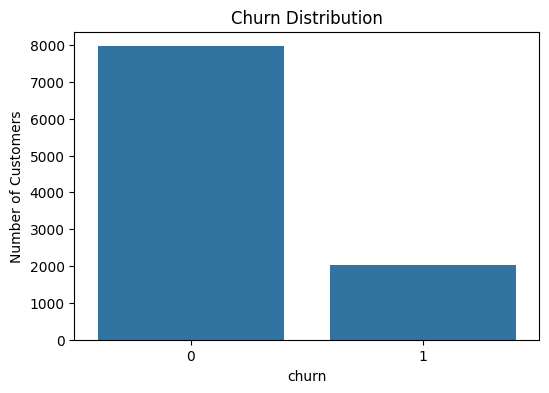

In [8]:
# Chrun Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.ylabel("Number of Customers")
plt.show()


# 5.Numerical Feature Exploration
This section explores numerical variables using histograms and boxplots. Histograms show distributions, while botxplots help identify possible outliers.

In [14]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_columns = [ 'credit_score','age','tenure','balance','estimated_salary']

numerical_columns

['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

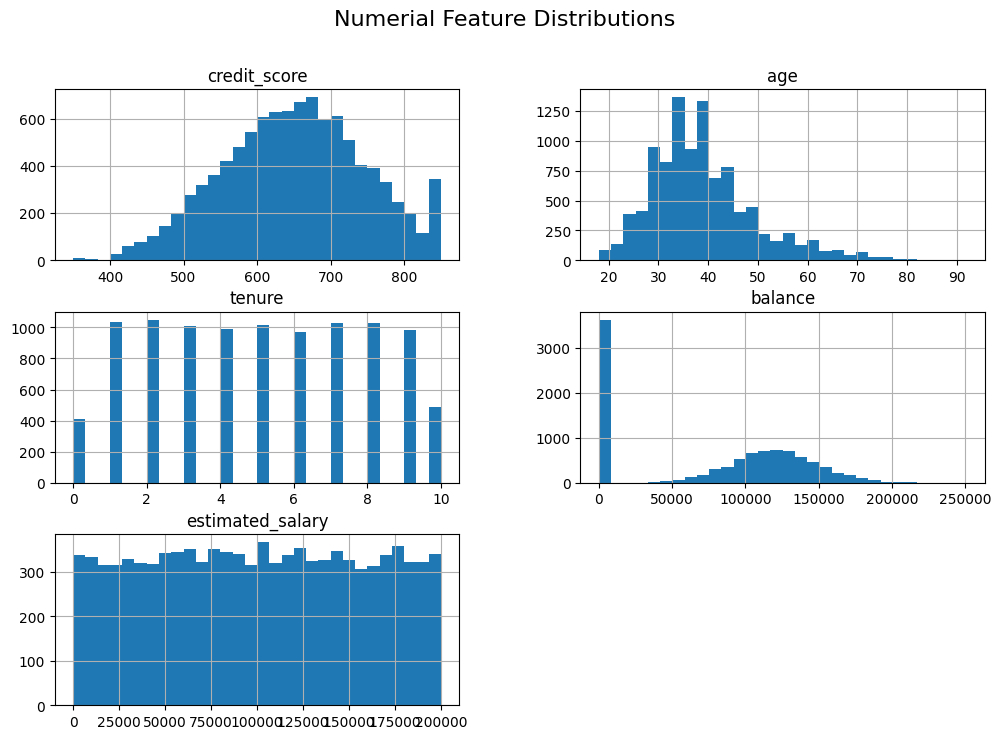

In [16]:
# Histograms for numerical features
df[numerical_columns].hist(figsize=(12, 8), bins=30)
plt.suptitle("Numerial Feature Distributions", fontsize=16)
plt.show()

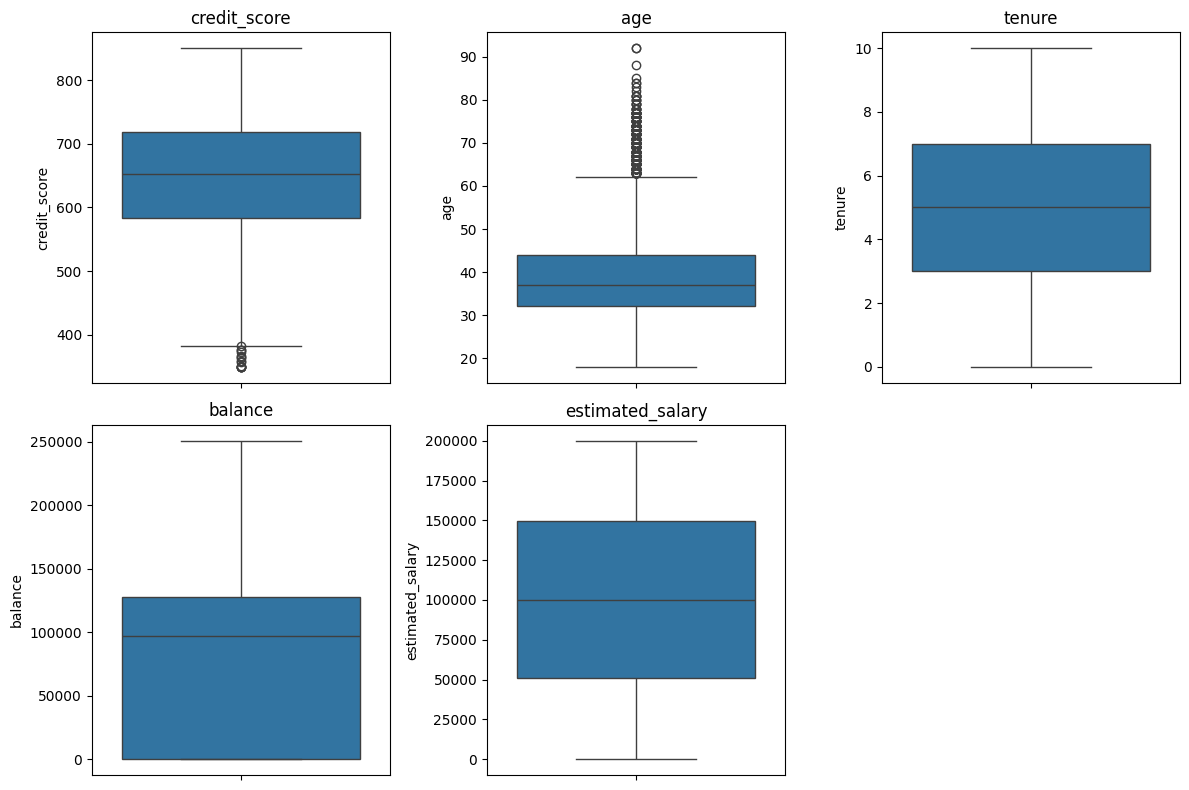

In [18]:
# Boxplots for numerical features
plt.figure(figsize=(12, 8))

for i, col in enumerate(numerical_columns, 1):
  plt.subplot(2, 3, i)
  sns.boxplot(y=df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

## Observations

The boxplots reveal that while most numerical features are reasonably distributed, age and credit score contain notable outliers, and balance shows a highly skewed distribution with a large proportion of zero values. Indicating distinct customer segments. These characteristics suggest that feature scaling and careful handling of outliers may be necessary before modeling.






# 5.Categorical Feature Exploration

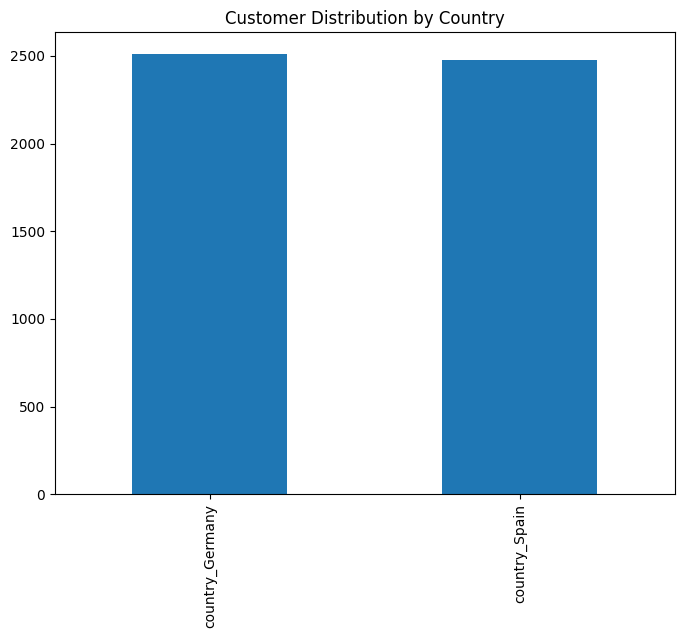

In [20]:
# Count plots for countries

country_cols = [col for col in df.columns if "country_" in col]

df[country_cols].sum().plot(kind="bar", figsize=(8, 6))
plt.title("Customer Distribution by Country")
plt.show()

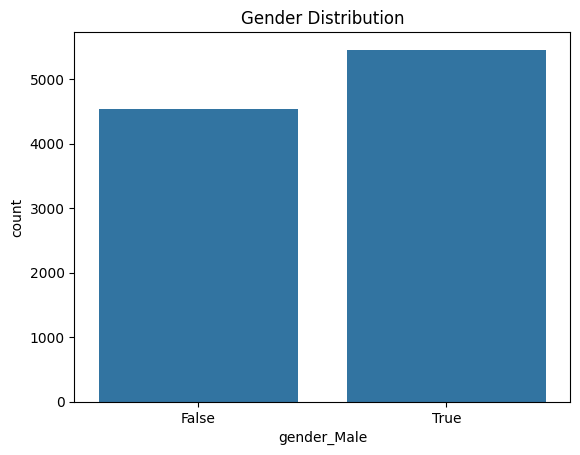

In [22]:
# For gender

sns.countplot(x="gender_Male", data=df)
plt.title("Gender Distribution")
plt.show()

## Observations

The categorical distributions show that customers are evenly distributed across countries, while gender exhibits a slight imbalance with more male customers than female ones. However neither feature demonstrates severe imbalance that would require immediate correction

# 7.Correlation Analysis

In [23]:
# Correlation Matrix
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
customer_id,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248,-0.003097,0.007800,-0.002641
credit_score,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780,-0.002857
age,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685,-0.027544
tenure,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868,0.014733
balance,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892,0.012087
products_number,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039,-0.021859
credit_card,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480,0.005766
active_member,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732,0.022544
estimated_salary,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482,-0.008112
churn,-0.006248,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667,-0.106512


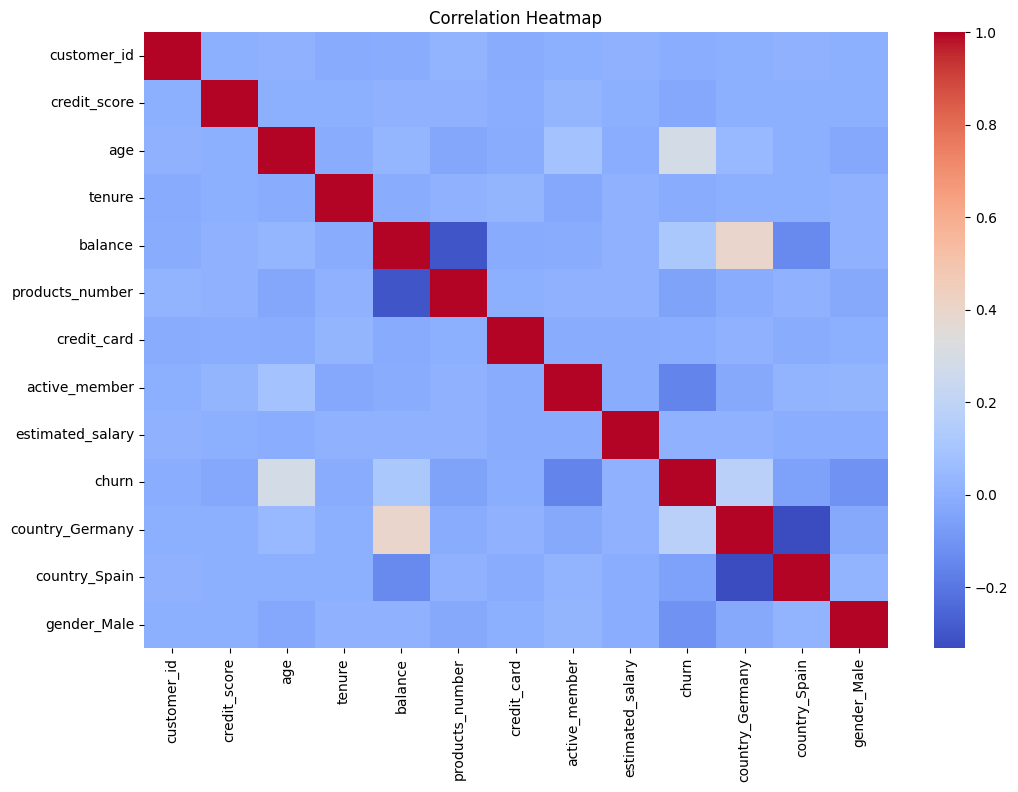

In [24]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
# Correlation of each feature with Churn
churn_corr = corr_matrix["churn"].sort_values(ascending=False)
churn_corr

,churn
churn,1.000000
age,0.285323
country_Germany,0.173488
balance,0.118533
estimated_salary,0.012097
customer_id,-0.006248
credit_card,-0.007138
tenure,-0.014001
credit_score,-0.027094
products_number,-0.047820


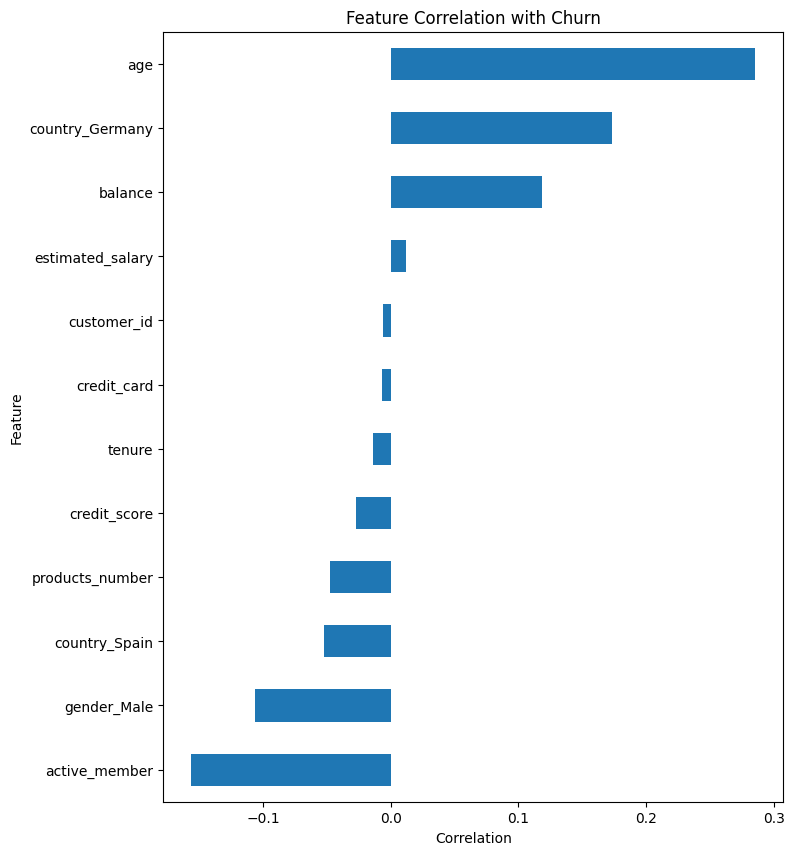

In [26]:
# Plot top correlations with Churn
churn_corr.drop("churn").sort_values().plot(kind="barh", figsize=(8, 10))
plt.title("Feature Correlation with Churn")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

## Observations
The correlation anaysis indicates that age is the most positively correlated feature with churn, followed by customers from germany and account balance. In contrast, active membership shows the strongest negative correlation, suggesting that engaged customers are less likely to leave. Most other features exhibit weak correlations, highlighting that churn behavior is likely influenced by a combination of variables rather than a single dominant factor.

# 8.Final EDA Insights

The dataset is generally well balanced, with no major issues in categorical distributions, although a notable segment of customers have zero balance, which may be important for modelling.

Overall, effective churn prediction will likely require feature engineering and models capable of capturing non linear relationships.